In [3]:
# ============================================================
# SPAM EMAIL DETECTION USING MACHINE LEARNING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud

In [4]:
# ============================================================
# 1. LOAD DATASET
# ============================================================
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv',
                 encoding='latin-1')

df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['label'].value_counts())
print(f"\nSpam %: {df['label'].value_counts(normalize=True)['spam']*100:.1f}%")
df.head()

Dataset shape: (5572, 2)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam %: 13.4%


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


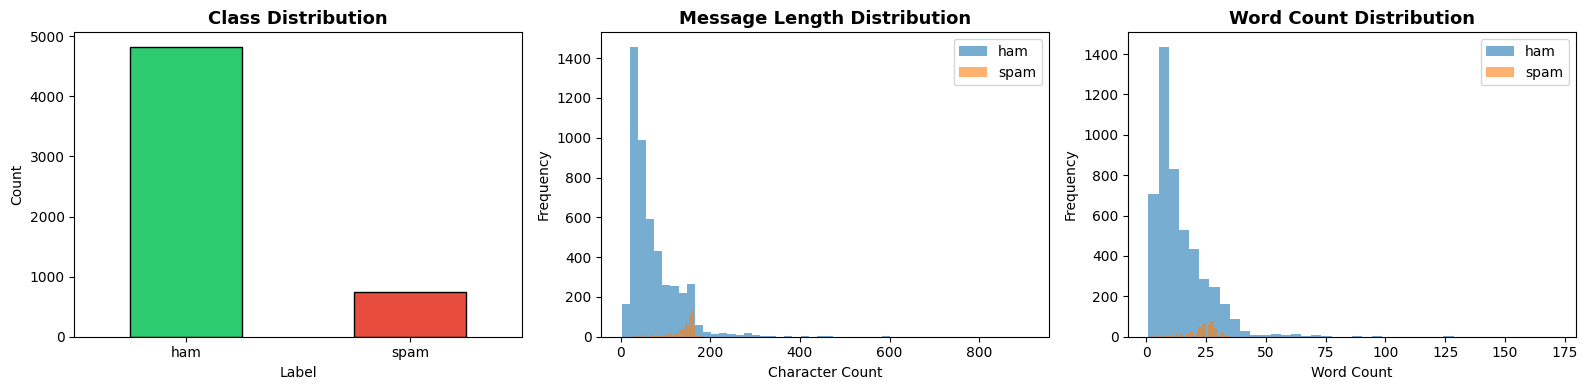


Average message length:
label
ham      71.023627
spam    138.866131
Name: msg_length, dtype: float64


In [5]:
# ============================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
df['msg_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
df['label'].value_counts().plot(kind='bar', ax=axes[0],
                                 color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Message length distribution
df.groupby('label')['msg_length'].plot(kind='hist', bins=50, alpha=0.6,
                                        ax=axes[1], legend=True)
axes[1].set_title('Message Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Character Count')

# Word count distribution
df.groupby('label')['word_count'].plot(kind='hist', bins=40, alpha=0.6,
                                        ax=axes[2], legend=True)
axes[2].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAverage message length:")
print(df.groupby('label')['msg_length'].mean())

In [6]:
# ============================================================
# 3. TEXT PREPROCESSING
# ============================================================
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\b\d{10,}\b', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_message'] = df['message'].apply(preprocess_text)
df['label_enc'] = (df['label'] == 'spam').astype(int)

print("Sample preprocessed messages:")
print(df[['message', 'clean_message', 'label']].head(3).to_string())


Sample preprocessed messages:
                                                                                                                                                       message                                                                                                                                          clean_message label
0                                              Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                                                 go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat   ham
1                                                                                                                                Ok lar... Joking wif u oni...                                                                                                                                ok lar joking wif u oni   ham
2  Free entry in 2 a w

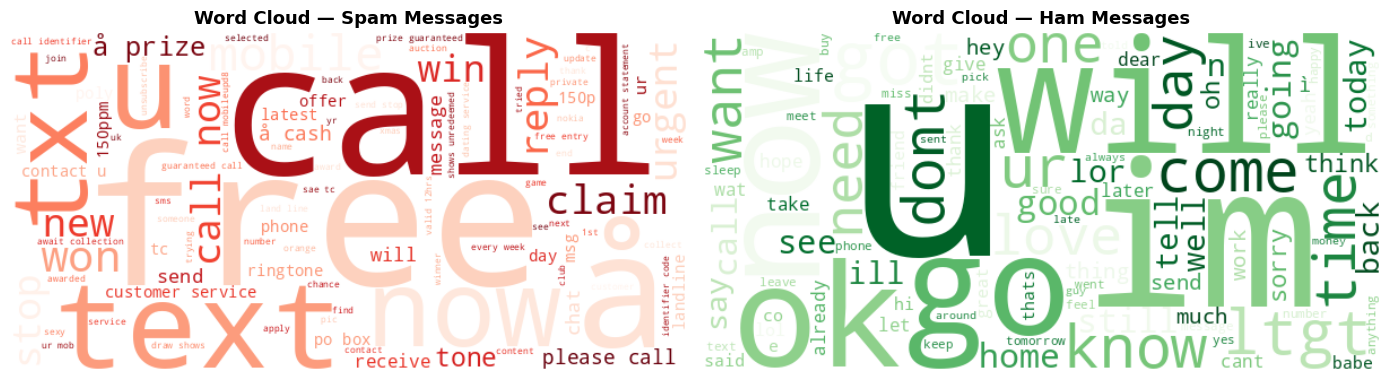

In [7]:
# ============================================================
# 4. WORD CLOUD VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, color, title in [
    (axes[0], 'spam', 'Reds',   'Spam Messages'),
    (axes[1], 'ham',  'Greens', 'Ham Messages')
]:
    text = ' '.join(df[df['label'] == label]['clean_message'])
    wc = WordCloud(width=600, height=300, background_color='white',
                   colormap=color, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {title}', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================
X = df['clean_message']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")


Training samples : 4457
Testing  samples : 1115


In [9]:
# ============================================================
# 6. TF-IDF VECTORIZATION
# ============================================================
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nTF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test) : {X_test_tfidf.shape}")

# Top spam terms — FIX: use .values to convert Series to numpy array
feature_names = tfidf.get_feature_names_out()
spam_mask = y_train == 1
spam_tfidf = X_train_tfidf[spam_mask.values].toarray().mean(axis=0)
top_spam_idx = spam_tfidf.argsort()[-15:][::-1]
print("\nTop 15 spam TF-IDF terms:")
print([feature_names[i] for i in top_spam_idx])



TF-IDF matrix shape (train): (4457, 5000)
TF-IDF matrix shape (test) : (1115, 5000)

Top 15 spam TF-IDF terms:
['free', 'txt', 'claim', 'stop', 'text', 'mobile', 'reply', 'ur', 'prize', 'new', 'service', 'won', 'urgent', 'cash', 'win']


In [10]:
# ============================================================
# 7. HANDLE CLASS IMBALANCE WITH SMOTE
# ============================================================
print("\nBefore SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_tfidf.toarray(), y_train)

print("After  SMOTE:", dict(zip(*np.unique(y_train_res, return_counts=True))))


Before SMOTE: {np.int64(0): np.int64(3859), np.int64(1): np.int64(598)}
After  SMOTE: {np.int64(0): np.int64(3859), np.int64(1): np.int64(3859)}


In [11]:
# ============================================================
# 8. MODEL 1 — NAIVE BAYES (on original TF-IDF, NB handles imbalance well)
# ============================================================
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)
nb_probs = nb_model.predict_proba(X_test_tfidf)[:, 1]

nb_acc = accuracy_score(y_test, nb_preds)
nb_auc = roc_auc_score(y_test, nb_probs)

print("=" * 45)
print("NAIVE BAYES RESULTS")
print("=" * 45)
print(f"Accuracy : {nb_acc*100:.2f}%")
print(f"ROC-AUC  : {nb_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, nb_preds, target_names=['Ham', 'Spam']))


NAIVE BAYES RESULTS
Accuracy : 98.12%
ROC-AUC  : 0.9886

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [12]:
# ============================================================
# 9. MODEL 2 — LOGISTIC REGRESSION (trained on SMOTE-balanced data)
# ============================================================
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res)
lr_preds = lr_model.predict(X_test_tfidf)
lr_probs = lr_model.predict_proba(X_test_tfidf)[:, 1]

lr_acc = accuracy_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_probs)

print("=" * 45)
print("LOGISTIC REGRESSION RESULTS (SMOTE)")
print("=" * 45)
print(f"Accuracy : {lr_acc*100:.2f}%")
print(f"ROC-AUC  : {lr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['Ham', 'Spam']))


LOGISTIC REGRESSION RESULTS (SMOTE)
Accuracy : 97.94%
ROC-AUC  : 0.9867

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.91      0.94      0.92       149

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



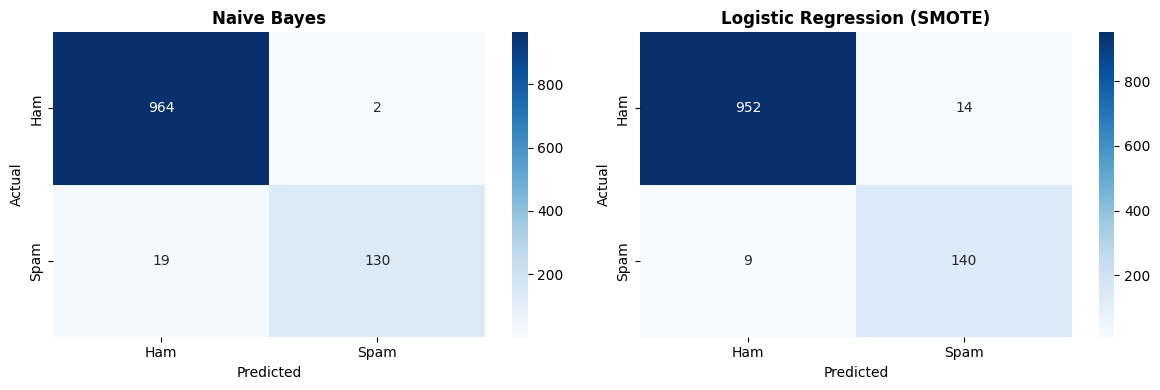

In [13]:
# ============================================================
# 10. CONFUSION MATRICES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(axes,
                              [nb_preds, lr_preds],
                              ['Naive Bayes', 'Logistic Regression (SMOTE)']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'])
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


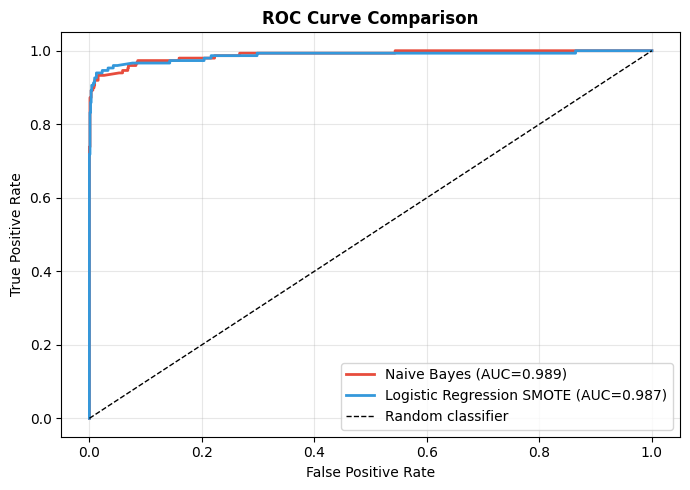

In [14]:
# ============================================================
# 11. ROC CURVES
# ============================================================
plt.figure(figsize=(7, 5))

for probs, label, color in [
    (nb_probs, f'Naive Bayes (AUC={nb_auc:.3f})',              '#e74c3c'),
    (lr_probs, f'Logistic Regression SMOTE (AUC={lr_auc:.3f})', '#3498db')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=label, color=color, lw=2)

plt.plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

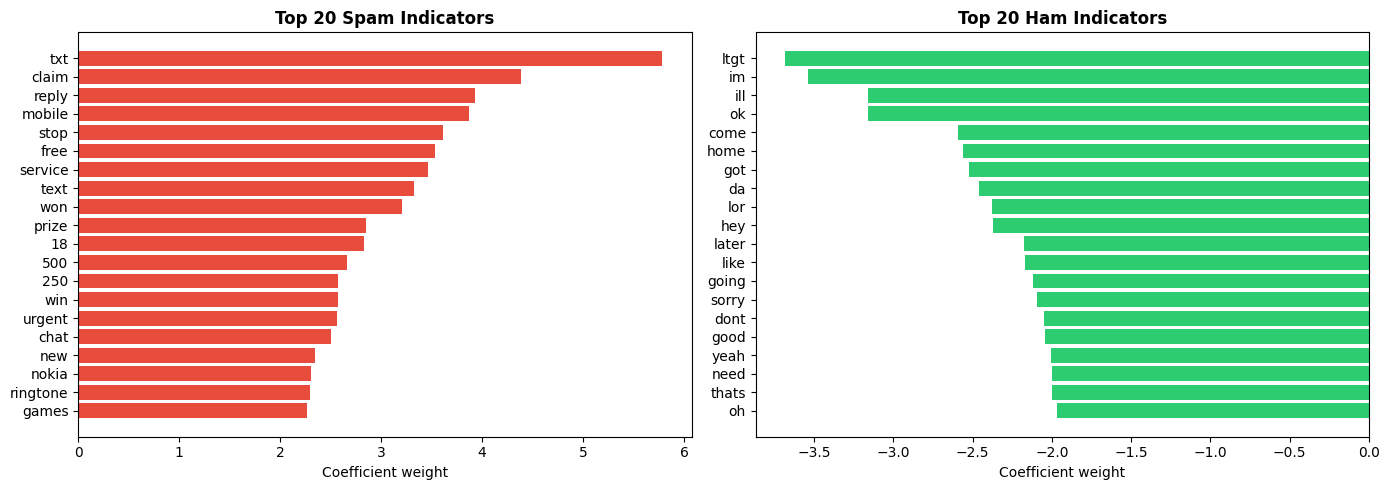

In [15]:
# ============================================================
# 12. TOP FEATURES — LOGISTIC REGRESSION COEFFICIENTS
# ============================================================
coef = lr_model.coef_[0]
top_spam_feat = np.argsort(coef)[-20:][::-1]
top_ham_feat  = np.argsort(coef)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh([feature_names[i] for i in top_spam_feat[::-1]],
              coef[top_spam_feat[::-1]], color='#e74c3c')
axes[0].set_title('Top 20 Spam Indicators', fontweight='bold')
axes[0].set_xlabel('Coefficient weight')

axes[1].barh([feature_names[i] for i in top_ham_feat[::-1]],
              coef[top_ham_feat[::-1]], color='#2ecc71')
axes[1].set_title('Top 20 Ham Indicators', fontweight='bold')
axes[1].set_xlabel('Coefficient weight')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ============================================================
# 13. CROSS-VALIDATION (proves model generalizes)
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "="*50)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("="*50)

for model, data_X, data_y, name in [
    (nb_model, X_train_tfidf, y_train,     'Naive Bayes'),
    (lr_model, X_train_res,   y_train_res, 'Logistic Regression (SMOTE)')
]:
    acc_scores = cross_val_score(model, data_X, data_y, cv=cv, scoring='accuracy')
    f1_scores  = cross_val_score(model, data_X, data_y, cv=cv, scoring='f1')
    print(f"\n{name}")
    print(f"  CV Accuracy : {acc_scores.mean()*100:.2f}% ± {acc_scores.std()*100:.2f}%")
    print(f"  CV F1-Score : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")



5-FOLD CROSS-VALIDATION RESULTS

Naive Bayes
  CV Accuracy : 98.38% ± 0.22%
  CV F1-Score : 0.9387 ± 0.0086

Logistic Regression (SMOTE)
  CV Accuracy : 95.56% ± 0.28%
  CV F1-Score : 0.9543 ± 0.0029


In [17]:
# ============================================================
# 14. HYPERPARAMETER TUNING WITH GRIDSEARCHCV
# ============================================================
print("\n" + "="*50)
print("GRIDSEARCHCV — LOGISTIC REGRESSION PIPELINE")
print("="*50)

param_grid = {
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range':  [(1, 1), (1, 2)],
    'clf__C':              [0.1, 1.0, 10.0]
}

grid_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=1000, random_state=42))
])

grid_search = GridSearchCV(grid_pipeline, param_grid,
                            cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters : {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
best_preds = best_model.predict(X_test)
best_probs = best_model.predict_proba(X_test)[:, 1]
best_acc   = accuracy_score(y_test, best_preds)
best_auc   = roc_auc_score(y_test, best_probs)

print(f"\nBest Model — Test Accuracy : {best_acc*100:.2f}%")
print(f"Best Model — ROC-AUC       : {best_auc:.4f}")
print("\nClassification Report (Best Model):")
print(classification_report(y_test, best_preds, target_names=['Ham', 'Spam']))


GRIDSEARCHCV — LOGISTIC REGRESSION PIPELINE
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters : {'clf__C': 10.0, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}
Best CV F1-Score: 0.9199

Best Model — Test Accuracy : 98.30%
Best Model — ROC-AUC       : 0.9878

Classification Report (Best Model):
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.88      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [18]:
# ============================================================
# 15. SAVE & LOAD MODEL
# ============================================================
joblib.dump(best_model, 'spam_detector.pkl')
print("\nModel saved → spam_detector.pkl")

loaded_model = joblib.load('spam_detector.pkl')
print("Model loaded successfully!")

# Quick sanity check
sanity_msgs = [
    "WIN a free prize! Click NOW to claim your reward!!!",
    "Hey, lunch at 1pm today? Let me know."
]
for msg in sanity_msgs:
    clean = preprocess_text(msg)
    pred  = loaded_model.predict([clean])[0]
    prob  = loaded_model.predict_proba([clean])[0][1]
    print(f"  {'SPAM' if pred==1 else 'HAM '} ({prob*100:.1f}%)  →  {msg}")



Model saved → spam_detector.pkl
Model loaded successfully!
  SPAM (97.5%)  →  WIN a free prize! Click NOW to claim your reward!!!
  HAM  (0.1%)  →  Hey, lunch at 1pm today? Let me know.


In [19]:
# ============================================================
# 16. FINAL PREDICTIONS ON CUSTOM MESSAGES
# ============================================================
test_messages = [
    "WINNER!! You've been selected for a FREE $1000 gift card. Call now!",
    "Hey, are you coming to the meeting at 3pm today?",
    "Claim your FREE prize. Limited offer. Click here NOW!!",
    "Can you send me the report before end of day? Thanks.",
    "Congratulations! You won a lottery. Send your bank details to claim.",
    "Your package has been dispatched. Expected delivery: Thursday.",
    "URGENT: Your account is suspended. Verify details immediately at link below.",
    "Are you free this weekend? We're planning a trip."
]

clean_test = [preprocess_text(m) for m in test_messages]
results = best_model.predict(clean_test)
proba   = best_model.predict_proba(clean_test)[:, 1]

print("\n" + "="*65)
print("FINAL PREDICTIONS (Best Tuned Model)")
print("="*65)
for msg, pred, prob in zip(test_messages, results, proba):
    label = "🚫 SPAM" if pred == 1 else "✅ HAM "
    bar   = "█" * int(prob * 20) + "░" * (20 - int(prob * 20))
    print(f"\n{label}  [{bar}] {prob*100:.1f}%")
    print(f"       {msg[:70]}")


FINAL PREDICTIONS (Best Tuned Model)

🚫 SPAM  [█████████████░░░░░░░] 66.2%
       WINNER!! You've been selected for a FREE $1000 gift card. Call now!

✅ HAM   [░░░░░░░░░░░░░░░░░░░░] 0.2%
       Hey, are you coming to the meeting at 3pm today?

🚫 SPAM  [██████████████████░░] 93.0%
       Claim your FREE prize. Limited offer. Click here NOW!!

✅ HAM   [█░░░░░░░░░░░░░░░░░░░] 6.9%
       Can you send me the report before end of day? Thanks.

🚫 SPAM  [██████████████████░░] 92.6%
       Congratulations! You won a lottery. Send your bank details to claim.

✅ HAM   [██░░░░░░░░░░░░░░░░░░] 11.7%
       Your package has been dispatched. Expected delivery: Thursday.

🚫 SPAM  [█████████████░░░░░░░] 65.7%
       URGENT: Your account is suspended. Verify details immediately at link 

✅ HAM   [██░░░░░░░░░░░░░░░░░░] 13.4%
       Are you free this weekend? We're planning a trip.


In [20]:
# ============================================================
# 17. FINAL MODEL COMPARISON SUMMARY
# ============================================================
summary = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Logistic Regression (SMOTE)',
        'LR Tuned — GridSearchCV (Best)'
    ],
    'Accuracy': [
        f"{nb_acc*100:.2f}%",
        f"{lr_acc*100:.2f}%",
        f"{best_acc*100:.2f}%"
    ],
    'ROC-AUC': [
        f"{nb_auc:.4f}",
        f"{lr_auc:.4f}",
        f"{best_auc:.4f}"
    ]
})

print("\n\n" + "="*55)
print("FINAL MODEL COMPARISON")
print("="*55)
print(summary.to_string(index=False))
print("\nBest overall model saved as: spam_detector.pkl")



FINAL MODEL COMPARISON
                         Model Accuracy ROC-AUC
                   Naive Bayes   98.12%  0.9886
   Logistic Regression (SMOTE)   97.94%  0.9867
LR Tuned — GridSearchCV (Best)   98.30%  0.9878

Best overall model saved as: spam_detector.pkl


In [22]:
import joblib
joblib.dump(best_model, 'spam_detector.pkl')

['spam_detector.pkl']